# Task 4.1: FedProx - Complete Implementation
**FedProx adds a proximal term to prevent client drift**

## Setup

In [1]:
import torch, time, sys
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import copy

# Import our custom modules
sys.path.append('/kaggle/input')
from scriptsfl.data_utils import load_dataset, create_dirichlet_split, get_dataloaders, analyze_data_distribution
from scriptsfl.models import SimpleCNN, get_model
from scriptsfl.federated_utils import get_model_weights, set_model_weights, evaluate_model
from scriptsfl.server import Server
from scriptsfl.results_utils import save_results, plot_comparison, print_summary

In [6]:
# Set random seeds
torch.manual_seed(42)
np.random.seed(42)

print("="*80)
print("TASK 4.1: FEDPROX IMPLEMENTATION")
print("="*80)

#%% Configuration
CONFIG = {
    'dataset': 'cifar10',
    'num_clients': 5,
    'num_rounds': {1:50, 5:10, 10:5, 25:2},
    # 'local_epochs': 1,
    'batch_size': 32,
    'lr': 0.01,
    'momentum': 0.9,
    'alpha': 0.1,  # Dirichlet parameter for non-IID data
    'device': 'cuda' if torch.cuda.is_available() else 'cpu'
}

print(f"\nDevice: {CONFIG['device']}")
print(f"Configuration: {CONFIG}\n")

TASK 4.1: FEDPROX IMPLEMENTATION

Device: cuda
Configuration: {'dataset': 'cifar10', 'num_clients': 5, 'num_rounds': {1: 50, 5: 10, 10: 5, 25: 2}, 'batch_size': 32, 'lr': 0.01, 'momentum': 0.9, 'alpha': 0.1, 'device': 'cuda'}



In [7]:
#%% Load and prepare NON-IID data
print("Loading dataset...")
train_dataset, test_dataset = load_dataset(CONFIG['dataset'])
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=2)

# Create NON-IID split using Dirichlet
print(f"\nCreating NON-IID split with alpha={CONFIG['alpha']}...")
client_indices = create_dirichlet_split(train_dataset, CONFIG['num_clients'],
                                       alpha=CONFIG['alpha'])
analyze_data_distribution(train_dataset, client_indices, num_classes=10)

# Create data loaders
client_loaders = get_dataloaders(train_dataset, client_indices,
                                  batch_size=CONFIG['batch_size'], shuffle=True)

Loading dataset...

Creating NON-IID split with alpha=0.1...

DATA DISTRIBUTION ANALYSIS

Client 0 (Total: 12872 samples):
  Class distribution: [0, 0, 4543, 5, 149, 4902, 3265, 0, 0, 8]
  Percentages: [0.0, 0.0, 35.29, 0.04, 1.16, 38.08, 25.37, 0.0, 0.0, 0.06]

Client 1 (Total: 14320 samples):
  Class distribution: [24, 3, 118, 0, 4767, 67, 117, 4710, 4514, 0]
  Percentages: [0.17, 0.02, 0.82, 0.0, 33.29, 0.47, 0.82, 32.89, 31.52, 0.0]

Client 2 (Total: 4982 samples):
  Class distribution: [0, 4435, 2, 0, 0, 0, 44, 160, 332, 9]
  Percentages: [0.0, 89.02, 0.04, 0.0, 0.0, 0.0, 0.88, 3.21, 6.66, 0.18]

Client 3 (Total: 13806 samples):
  Class distribution: [1496, 561, 313, 4660, 83, 9, 1573, 129, 0, 4982]
  Percentages: [10.84, 4.06, 2.27, 33.75, 0.6, 0.07, 11.39, 0.93, 0.0, 36.09]

Client 4 (Total: 4020 samples):
  Class distribution: [3480, 1, 24, 335, 1, 22, 1, 1, 154, 1]
  Percentages: [86.57, 0.02, 0.6, 8.33, 0.02, 0.55, 0.02, 0.02, 3.83, 0.02]



## FedProx classes

In [12]:
#%% FedProx Client Implementation

class FedProxClient:
    """
    FedProx Client with proximal term regularization
    """

    def __init__(self, client_id, data_loader, model, device='cpu'):
        self.client_id = client_id
        self.data_loader = data_loader
        self.device = device
        self.model = copy.deepcopy(model).to(device)
        self.data_size = len(data_loader.dataset)
        self.global_weights = None  # Store global weights for proximal term

    def train_local(self, epochs, lr, mu, momentum=0.9):
        """
        Train locally with FedProx proximal term

        Args:
            epochs: number of local epochs
            lr: learning rate
            mu: proximal term coefficient
            momentum: SGD momentum

        Returns:
            dict with training stats
        """
        self.model.train()
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.SGD(self.model.parameters(), lr=lr, momentum=momentum)

        # Store global weights at the start of this round
        if self.global_weights is None:
            self.global_weights = get_model_weights(self.model)

        epoch_losses = []

        for epoch in range(epochs):
            running_loss = 0.0
            for data, target in self.data_loader:
                data, target = data.to(self.device), target.to(self.device)

                optimizer.zero_grad()
                output = self.model(data)

                # Standard loss
                loss = criterion(output, target)

                # Add proximal term: (mu/2) * ||w - w_global||^2
                if mu > 0:
                    proximal_term = 0.0
                    for param, global_param in zip(self.model.parameters(), self.global_weights):
                        proximal_term += torch.norm(param - global_param.to(self.device)) ** 2
                    loss += (mu / 2) * proximal_term

                loss.backward()
                optimizer.step()

                running_loss += loss.item() * data.size(0)

            epoch_loss = running_loss / self.data_size
            epoch_losses.append(epoch_loss)

        stats = {
            'client_id': self.client_id,
            'epochs': epochs,
            'final_loss': epoch_losses[-1],
            'epoch_losses': epoch_losses
        }

        return stats

    def get_weights(self):
        return get_model_weights(self.model)

    def set_weights(self, weights):
        set_model_weights(self.model, weights)
        self.global_weights = [w.clone() for w in weights]  # Update global weights

    def get_data_size(self):
        return self.data_size


#%% FedProx Server (modified to use FedProx clients)

class FedProxServer(Server):
    """
    Server for FedProx (uses FedProx clients)
    """

    def train_round(self, local_epochs, lr, mu, client_fraction=1.0, momentum=0.9):
        """
        Execute one round of FedProx training
        """
        # Select clients
        selected_clients = self.select_clients(fraction=client_fraction)

        # Broadcast global model
        self.broadcast_weights(selected_clients)

        # Local training with proximal term
        client_stats = []
        for client in selected_clients:
            stats = client.train_local(epochs=local_epochs, lr=lr, mu=mu, momentum=momentum)
            client_stats.append(stats)

        # Aggregate
        divergence = self.aggregate(selected_clients)

        # Evaluate
        test_acc, test_loss = self.evaluate()
        avg_train_loss = np.mean([s['final_loss'] for s in client_stats])

        round_stats = {
            'test_accuracy': test_acc,
            'test_loss': test_loss,
            'train_loss': avg_train_loss,
            'divergence': divergence,
            'num_clients': len(selected_clients)
        }

        return round_stats

    def train(self, num_rounds, local_epochs, lr, mu, client_fraction=1.0, momentum=0.9, verbose=True):
        """
        Train for multiple rounds with FedProx
        """
        for round_idx in range(num_rounds):
            round_stats = self.train_round(local_epochs, lr, mu, client_fraction, momentum)

            # Update history
            self.history['rounds'].append(round_idx + 1)
            self.history['test_accuracy'].append(round_stats['test_accuracy'])
            self.history['test_loss'].append(round_stats['test_loss'])
            self.history['train_loss'].append(round_stats['train_loss'])
            self.history['divergence'].append(round_stats['divergence'])

            if verbose:
                print(f"Round {round_idx + 1}/{num_rounds} | "
                      f"Test Acc: {round_stats['test_accuracy']:.2f}% | "
                      f"Test Loss: {round_stats['test_loss']:.4f} | "
                      f"Train Loss: {round_stats['train_loss']:.4f} | "
                      f"Divergence: {round_stats['divergence']:.4f}")

        return self.history

## Experiment: Compare FedAvg vs FedProx

In [13]:
import time

results_fedprox = {}

print("\n" + "="*80)
print("COMPARING FEDAVG VS FEDPROX (Non-IID Data)")
print("="*80)

mu_values = [0.001, 0.01, 0.1]
K_values = [1, 5, 10, 25]

for K in K_values:
    for mu in mu_values:
        method_name = f"K={K}, mu={mu}"
        print(f"\n--- Training FedProx with K={K}, µ={mu} ---")

        # Initialize model
        model = get_model('simplecnn', num_classes=10, dataset=CONFIG['dataset'])

        # Create FedProx clients
        clients = [
            FedProxClient(client_id=i, data_loader=client_loaders[i], model=model, device=CONFIG['device'])
            for i in range(CONFIG['num_clients'])
        ]

        # Create server
        server = FedProxServer(global_model=model, clients=clients, test_loader=test_loader, device=CONFIG['device'])

        # Train
        start_time = time.time()
        history = server.train(
            num_rounds=CONFIG['num_rounds'][K],
            local_epochs=K,
            lr=CONFIG['lr'],
            mu=mu,
            client_fraction=1.0,
            momentum=CONFIG['momentum'],
            verbose=True
        )
        end_time = time.time()
        duration = end_time - start_time

        # Save results
        results_fedprox[method_name] = {
            'history': history,
            'config': {**CONFIG, 'local_epochs': K, 'mu': mu},
            'time_minutes': round(duration / 60, 2)
        }

        print(f"\nFinal accuracy with {method_name}: {history['test_accuracy'][-1]:.2f}%")
        print(f"Training time: {duration/60:.2f} minutes")


COMPARING FEDAVG VS FEDPROX (Non-IID Data)

--- Training FedProx with K=1, µ=0.001 ---
Round 1/50 | Test Acc: 17.70% | Test Loss: 2.1810 | Train Loss: 0.7987 | Divergence: 3.0446
Round 2/50 | Test Acc: 37.95% | Test Loss: 1.8956 | Train Loss: 0.7249 | Divergence: 2.8404
Round 3/50 | Test Acc: 42.48% | Test Loss: 1.6894 | Train Loss: 0.6613 | Divergence: 2.7195
Round 4/50 | Test Acc: 45.47% | Test Loss: 1.5441 | Train Loss: 0.6023 | Divergence: 2.6751
Round 5/50 | Test Acc: 52.67% | Test Loss: 1.4006 | Train Loss: 0.5783 | Divergence: 2.7246
Round 6/50 | Test Acc: 52.83% | Test Loss: 1.3381 | Train Loss: 0.5567 | Divergence: 2.7340
Round 7/50 | Test Acc: 57.63% | Test Loss: 1.2581 | Train Loss: 0.5298 | Divergence: 2.7804
Round 8/50 | Test Acc: 56.37% | Test Loss: 1.2352 | Train Loss: 0.5100 | Divergence: 2.8225
Round 9/50 | Test Acc: 59.12% | Test Loss: 1.2028 | Train Loss: 0.4947 | Divergence: 2.8628
Round 10/50 | Test Acc: 59.76% | Test Loss: 1.1583 | Train Loss: 0.4818 | Divergence

Results saved to ./results/task4_1_fedprox.json
Figure saved to ./results/task4_1_fedprox_comparison_acc.png


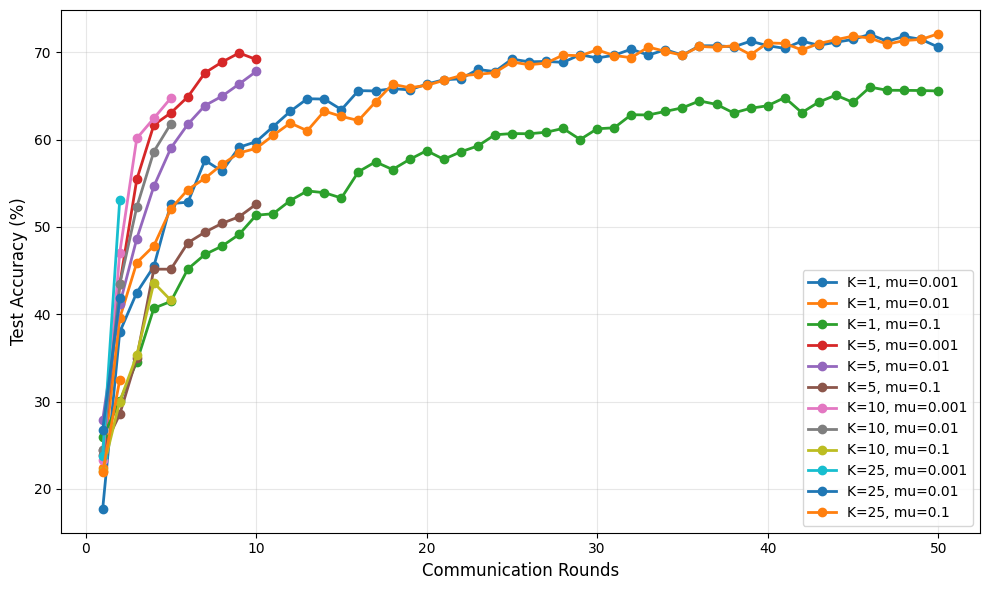

Figure saved to ./results/task4_1_fedprox_comparison_loss.png


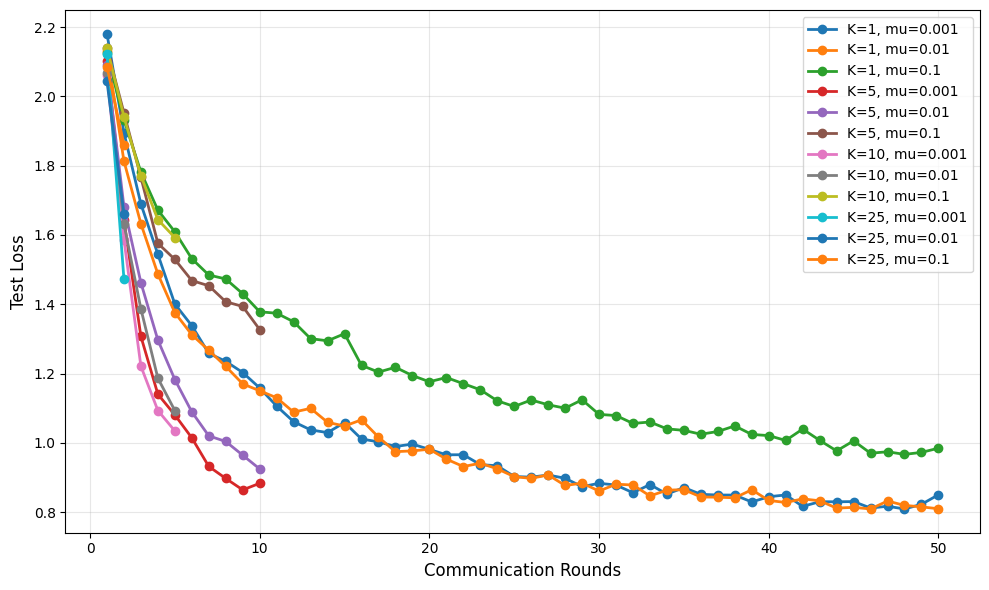

Figure saved to ./results/task4_1_fedprox_comparison_divergence.png


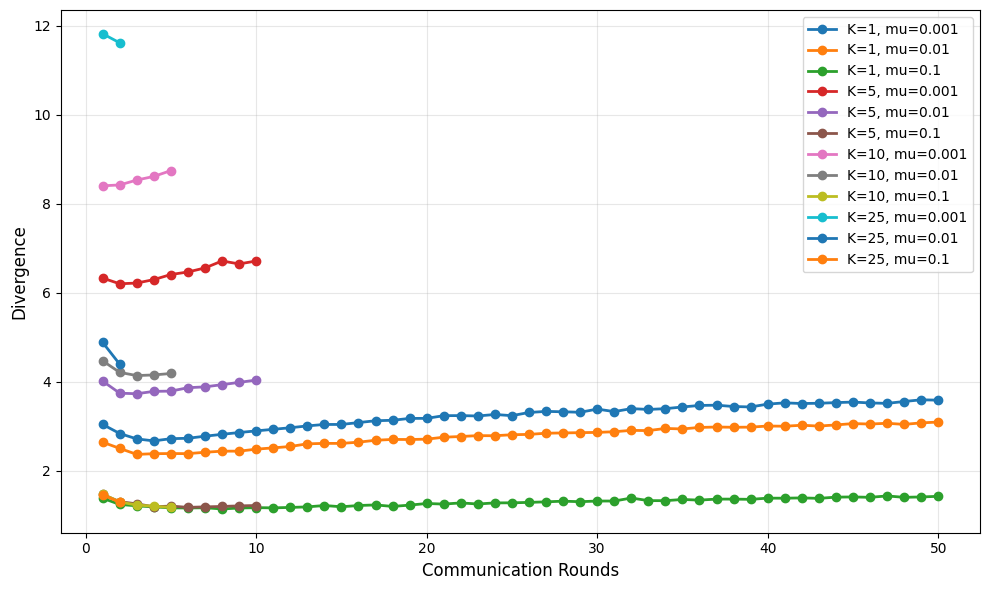

In [20]:
# Save all results
save_results(results_fedprox, 'task4_1_fedprox')

# Plot comparison
plot_comparison(results_fedprox, metric='test_accuracy', title=None, save_path='./results/task4_1_fedprox_comparison_acc.png')
plot_comparison(results_fedprox, metric='test_loss', title=None, save_path='./results/task4_1_fedprox_comparison_loss.png')
plot_comparison(results_fedprox, metric='divergence', title=None, save_path='./results/task4_1_fedprox_comparison_divergence.png')

## Analysis

In [18]:
import matplotlib.pyplot as plt
import numpy as np

def plot_fed_comparison(all_results, metric='test_accuracy', save_path=None):
    """
    Plot combined results for FedAvg and FedProx over varying K and mu values.

    Args:
        all_results: dict structured as:
            {
                'FedAvg': {K1: {mu1: history_dict, mu2: ...}, K2: ...},
                'FedProx': {K1: {mu1: history_dict, ...}, ...}
            }
        metric: metric to plot ('test_accuracy' or 'test_loss')
        save_path: optional path to save figure
    """
    plt.figure(figsize=(12, 7))
    markers = ['o', 's', '^', 'D', 'v', '*']
    colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown']
    
    for i, algo_name in enumerate(all_results.keys()):
        algo_results = all_results[algo_name]
        for j, K in enumerate(sorted(algo_results.keys())):
            mu_results = algo_results[K]
            for k_idx, mu in enumerate(sorted(mu_results.keys())):
                history = mu_results[mu]['history'] if 'history' in mu_results[mu] else mu_results[mu]
                rounds = history.get('rounds', range(1, len(history[metric]) + 1))
                values = history[metric]
                label = f"{algo_name}, K={K}, μ={mu}"
                plt.plot(rounds, values, marker=markers[k_idx % len(markers)],
                         color=colors[j % len(colors)], linewidth=2, label=label)
    
    plt.xlabel('Communication Rounds', fontsize=12)
    plt.ylabel('Test Accuracy (%)' if metric=='test_accuracy' else 'Test Loss', fontsize=12)
    plt.title('FedAvg vs FedProx Comparison', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=10, ncol=2)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to {save_path}")
    
    plt.show()

import matplotlib.pyplot as plt
import numpy as np

def plot_fed_grid(all_results, metric='test_accuracy', save_path=None):
    """
    Plot FedAvg vs FedProx results in a grid layout by K and μ.

    Args:
        all_results: dict structured as:
            {
                'FedAvg': {K1: {mu1: history_dict, mu2: ...}, K2: ...},
                'FedProx': {K1: {mu1: history_dict, ...}, ...}
            }
        metric: metric to plot ('test_accuracy' or 'test_loss')
        save_path: optional path to save figure
    """
    algorithms = list(all_results.keys())
    K_values = sorted(next(iter(all_results.values())).keys())
    mu_values = sorted(next(iter(next(iter(all_results.values())).values())).keys())

    n_rows = len(K_values)
    n_cols = len(algorithms)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows), sharex=True, sharey=True)
    
    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = axes[np.newaxis, :]
    elif n_cols == 1:
        axes = axes[:, np.newaxis]

    markers = ['o', 's', '^', 'D', 'v', '*']
    colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown']

    for i, K in enumerate(K_values):
        for j, algo_name in enumerate(algorithms):
            ax = axes[i, j]
            mu_results = all_results[algo_name][K]
            for k_idx, mu in enumerate(mu_values):
                history = mu_results[mu]['history'] if 'history' in mu_results[mu] else mu_results[mu]
                rounds = history.get('rounds', range(1, len(history[metric]) + 1))
                values = history[metric]
                label = f"μ={mu}"
                ax.plot(rounds, values, marker=markers[k_idx % len(markers)],
                        color=colors[k_idx % len(colors)], linewidth=2, label=label)

            ax.set_title(f"{algo_name} | K={K}", fontsize=12, fontweight='bold')
            ax.set_xlabel('Communication Rounds')
            ax.set_ylabel('Test Accuracy (%)' if metric=='test_accuracy' else 'Test Loss')
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=9)

    plt.suptitle(f'FedAvg vs FedProx Comparison ({metric})', fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0, 0, 1, 0.96])

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to {save_path}")

    plt.show()

In [34]:
# Paths
fedavg_path = '/kaggle/input/fedavg/task2_varying_K.json'
fedprox_path = '/kaggle/working/results/task4_1_fedprox.json'
all_results_path = './results/all_results.json'
os.makedirs('./results', exist_ok=True)

# Load results
with open(fedavg_path, 'r') as f:
    fedavg_results = json.load(f)

with open(fedprox_path, 'r') as f:
    fedprox_results = json.load(f)

# # Process FedAvg: assign mu='0' for compatibility
# fedavg_processed = {}
# for K_key, data in fedavg_results.items():  # e.g., "K=1"
#     fedavg_processed[K_key] = {'0': data['history']}  # only keep history, mu=0

# # Process FedProx: keep existing mu values
# fedprox_processed = {}
# for K_key, mu_dict in fedprox_results.items():  # e.g., "K=5"
#     fedprox_processed[K_key] = {}
#     for mu_key, data in mu_dict.items():
#         # print(f"K_key={K_key}, mu_key={mu_key}, data.keys()={list(data.keys())}")
#         fedprox_processed[K_key][mu_key] = data

# # Merge into one dict
# all_results = {
#     'FedAvg': fedavg_processed,
#     'FedProx': fedprox_processed
# }

# # Save merged JSON
# with open(all_results_path, 'w') as f:
#     json.dump(all_results, f, indent=4)
# print(f"Merged results saved to {all_results_path}")

# ✅ Fixed processing of FedAvg and FedProx
fedavg_processed = {}
for K_key, data in fedavg_results.items():  # e.g., "K=1"
    # Wrap all metrics under 'history' to match FedProx
    fedavg_processed[K_key] = {'0': {'history': data}}

fedprox_processed = {}
for K_key, mu_dict in fedprox_results.items():  # e.g., "K=5"
    fedprox_processed[K_key] = {}
    for mu_key, data in mu_dict.items():
        # # Wrap all metrics under 'history' if not already
        # if 'history' not in data:
        #     fedprox_processed[K_key][mu_key] = {'history': data}
        # else:
            fedprox_processed[K_key][mu_key] = data

# Merge into one dict
all_results = {
    'FedAvg': fedavg_processed,
    'FedProx': fedprox_processed
}

# Save merged JSON
with open(all_results_path, 'w') as f:
    json.dump(all_results, f, indent=4)
print(f"Merged results saved to {all_results_path}")

Merged results saved to ./results/all_results.json


In [38]:
# Print summary
print("\n" + "="*80)
print("TASK 4.1: SUMMARY")
print("="*80)
print_summary(results_fedprox)

print("\nKey Observations:")
print("1. FedProx adds a proximal term (mu/2)||w - w_global||^2 to local objectives")
print("2. This regularization prevents clients from drifting too far from global model")
print("3. Trade-off: Higher mu stabilizes training but may bias the solution")
print("4. Optimal mu depends on the degree of heterogeneity")

print("\n" + "="*80)
print("TASK 4.1 COMPLETE - Results saved!")
print("="*80)


TASK 4.1: SUMMARY

EXPERIMENTAL RESULTS SUMMARY

K=1, mu=0.001:
  Final Test Accuracy: 70.59%
  Best Test Accuracy:  72.06%
  Final Test Loss:     0.8499
  Final Divergence: 3.5902
  Average Divergence: 3.2293
  Configuration:
    dataset: cifar10
    num_clients: 5
    num_rounds: {1: 50, 5: 10, 10: 5, 25: 2}
    batch_size: 32
    lr: 0.01
    momentum: 0.9
    alpha: 0.1
    device: cuda
    local_epochs: 1
    mu: 0.001

K=1, mu=0.01:
  Final Test Accuracy: 72.12%
  Best Test Accuracy:  72.12%
  Final Test Loss:     0.8095
  Final Divergence: 3.0982
  Average Divergence: 2.7812
  Configuration:
    dataset: cifar10
    num_clients: 5
    num_rounds: {1: 50, 5: 10, 10: 5, 25: 2}
    batch_size: 32
    lr: 0.01
    momentum: 0.9
    alpha: 0.1
    device: cuda
    local_epochs: 1
    mu: 0.01

K=1, mu=0.1:
  Final Test Accuracy: 65.57%
  Best Test Accuracy:  66.01%
  Final Test Loss:     0.9843
  Final Divergence: 1.4298
  Average Divergence: 1.2950
  Configuration:
    dataset: cif